# Notebook 3: Combined Model — Structured + NLP Knowledge Transfer
**Topic:** NLP-Enhanced Knowledge Transfer for Energy Consumption Prediction in Data-Scarce Electric Vehicles

This notebook covers:
- Loading saved models and NLP artifacts from Notebook 1 & 2
- Applying NLP knowledge weights to feature engineering
- Training an NLP-enhanced combined model
- Comparing: Structured-only vs NLP-Enhanced models
- Final evaluation and visualization
- Saving the final best model

## Step 1: Install & Import

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost tensorflow joblib sentence-transformers

In [2]:
import os
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge

from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('All libraries imported!')

All libraries imported!


## Step 2: Load Dataset and Saved Artifacts

In [3]:
# -----------------------------------------------
# 2.1 - Load raw dataset
# -----------------------------------------------

df = pd.read_csv('../data/EV_Energy_Consumption_Dataset.csv')
print('Dataset loaded:', df.shape)

Dataset loaded: (5000, 19)


In [5]:
# -----------------------------------------------
# 2.2 - Load saved models from Notebook 1
# -----------------------------------------------

rf_model        = joblib.load('../saved_models/random_forest_model.pkl')
xgb_model       = joblib.load('../saved_models/xgboost_model.pkl')
lstm_model      = load_model('../saved_models/lstm_model.keras')
scaler          = joblib.load('../saved_models/scaler.pkl')
feature_cols    = joblib.load('../saved_models/feature_cols.pkl')
best_model_name = joblib.load('../saved_models/best_model_name.pkl')

print('Structured models loaded!')
print(f'Best model from Notebook 1: {best_model_name}')
print(f'Features: {len(feature_cols)}')

Structured models loaded!
Best model from Notebook 1: LSTM
Features: 23


In [6]:
# -----------------------------------------------
# 2.3 - Load NLP artifacts from Notebook 2
# -----------------------------------------------

domain_knowledge_vector = np.load('../saved_models/domain_knowledge_vector.npy')
sentence_embeddings     = np.load('../saved_models/sentence_embeddings.npy')
tfidf_vectorizer        = joblib.load('../saved_models/tfidf_vectorizer.pkl')

with open('../saved_models/knowledge_weights.json', 'r') as f:
    knowledge_weights = json.load(f)

with open('../saved_models/knowledge_rules.json', 'r') as f:
    knowledge_rules = json.load(f)

print('NLP artifacts loaded!')
print(f'Domain knowledge vector: {domain_knowledge_vector.shape}')
print(f'Sentence embeddings: {sentence_embeddings.shape}')
print(f'Knowledge weights: {knowledge_weights}')

NLP artifacts loaded!
Domain knowledge vector: (384,)
Sentence embeddings: (1000, 384)
Knowledge weights: {'Speed_kmh': 0.0, 'Temperature_C': 1.0, 'Battery_Temperature_C': 0.5714, 'Slope_%': 0.0714, 'Driving_Mode': 0.0, 'Tire_Pressure_psi': 0.0714, 'Wind_Speed_ms': 0.0, 'Humidity_%': 0.0}


## Step 3: Reproduce Features (same as Notebook 1)

In [7]:
# -----------------------------------------------
# 3.1 - Feature engineering (same as Notebook 1)
# -----------------------------------------------

df['Timestamp']       = pd.to_datetime(df['Timestamp'])
df['Hour']            = df['Timestamp'].dt.hour
df['DayOfWeek']       = df['Timestamp'].dt.dayofweek
df['Month']           = df['Timestamp'].dt.month
df['Speed_x_Weight']  = df['Speed_kmh'] * df['Vehicle_Weight_kg']
df['Temp_x_Battery']  = df['Temperature_C'] * df['Battery_State_%']
df['Accel_x_Speed']   = df['Acceleration_ms2'] * df['Speed_kmh']
df['Wind_Resistance'] = df['Wind_Speed_ms'] ** 2

X = df[feature_cols]
y = df['Energy_Consumption_kWh']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Features reproduced and split done!')
print('Train:', X_train_scaled.shape, '| Test:', X_test_scaled.shape)

Features reproduced and split done!
Train: (4000, 23) | Test: (1000, 23)


## Step 4: Apply NLP Knowledge Transfer

In [8]:
# -----------------------------------------------
# 4.1 - Apply knowledge weights to features
# NLP tells us which features are more important
# We amplify those features using extracted weights
# -----------------------------------------------

def apply_knowledge_weights(X_scaled, feature_cols, knowledge_weights, boost_factor=1.5):
    """
    Amplify features that NLP identified as important.
    boost_factor: how much to multiply the NLP-important features
    """
    X_boosted = X_scaled.copy()
    for i, col in enumerate(feature_cols):
        if col in knowledge_weights and knowledge_weights[col] > 0:
            weight = knowledge_weights[col]
            X_boosted[:, i] = X_scaled[:, i] * (1 + weight * boost_factor)
    return X_boosted


X_train_nlp = apply_knowledge_weights(X_train_scaled, feature_cols, knowledge_weights)
X_test_nlp  = apply_knowledge_weights(X_test_scaled,  feature_cols, knowledge_weights)

print('NLP knowledge weights applied!')
print('Feature shape unchanged:', X_train_nlp.shape)

# Show which features were boosted
print('\nFeatures boosted by NLP knowledge:')
for feat, w in sorted(knowledge_weights.items(), key=lambda x: -x[1]):
    if w > 0:
        print(f'  {feat:<30}: weight = {w}')

NLP knowledge weights applied!
Feature shape unchanged: (4000, 23)

Features boosted by NLP knowledge:
  Temperature_C                 : weight = 1.0
  Battery_Temperature_C         : weight = 0.5714
  Slope_%                       : weight = 0.0714
  Tire_Pressure_psi             : weight = 0.0714


In [9]:
# -----------------------------------------------
# 4.2 - Add NLP embedding features
# Use PCA to compress domain knowledge vector
# and append as additional features
# -----------------------------------------------

from sklearn.decomposition import PCA

# Use PCA to reduce sentence embeddings to N components
N_COMPONENTS = 10
pca = PCA(n_components=N_COMPONENTS, random_state=42)
pca.fit(sentence_embeddings)

# Transform the domain knowledge vector
domain_vec_compressed = pca.transform(domain_knowledge_vector.reshape(1, -1))  # (1, N)

# Repeat for all training and test samples (same domain knowledge for all)
nlp_feat_train = np.tile(domain_vec_compressed, (X_train_nlp.shape[0], 1))
nlp_feat_test  = np.tile(domain_vec_compressed, (X_test_nlp.shape[0], 1))

# Concatenate NLP features to existing features
X_train_combined = np.hstack([X_train_nlp, nlp_feat_train])
X_test_combined  = np.hstack([X_test_nlp,  nlp_feat_test])

print(f'Original features: {X_train_scaled.shape[1]}')
print(f'NLP features added: {N_COMPONENTS}')
print(f'Combined features: {X_train_combined.shape[1]}')

Original features: 23
NLP features added: 10
Combined features: 33


## Step 5: Train NLP-Enhanced Models

In [10]:
# Helper evaluation function
def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'\n--- {name} ---')
    print(f'  MAE  : {mae:.4f}')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  R²   : {r2:.4f}')
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

all_results = []

In [11]:
# -----------------------------------------------
# 5.1 - Baseline: Structured-only (from Notebook 1)
# -----------------------------------------------

rf_pred_base  = rf_model.predict(X_test_scaled)
xgb_pred_base = xgb_model.predict(X_test_scaled)

X_test_lstm3d = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])
lstm_pred_base = lstm_model.predict(X_test_lstm3d).flatten()

all_results.append(evaluate_model('RF (Structured Only)',   y_test, rf_pred_base))
all_results.append(evaluate_model('XGB (Structured Only)',  y_test, xgb_pred_base))
all_results.append(evaluate_model('LSTM (Structured Only)', y_test, lstm_pred_base))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

--- RF (Structured Only) ---
  MAE  : 0.5227
  RMSE : 0.6560
  R²   : 0.9112

--- XGB (Structured Only) ---
  MAE  : 0.4831
  RMSE : 0.6046
  R²   : 0.9246

--- LSTM (Structured Only) ---
  MAE  : 0.4369
  RMSE : 0.5493
  R²   : 0.9378


In [12]:
# -----------------------------------------------
# 5.2 - NLP-Enhanced Random Forest
# -----------------------------------------------

rf_nlp = RandomForestRegressor(
    n_estimators=200, max_depth=20,
    min_samples_split=5, random_state=42, n_jobs=-1
)
rf_nlp.fit(X_train_combined, y_train)
rf_nlp_pred = rf_nlp.predict(X_test_combined)

all_results.append(evaluate_model('RF (NLP-Enhanced)', y_test, rf_nlp_pred))


--- RF (NLP-Enhanced) ---
  MAE  : 0.5233
  RMSE : 0.6572
  R²   : 0.9109


In [13]:
# -----------------------------------------------
# 5.3 - NLP-Enhanced XGBoost
# -----------------------------------------------

xgb_nlp = XGBRegressor(
    n_estimators=300, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbosity=0
)
xgb_nlp.fit(X_train_combined, y_train,
            eval_set=[(X_test_combined, y_test)], verbose=False)
xgb_nlp_pred = xgb_nlp.predict(X_test_combined)

all_results.append(evaluate_model('XGB (NLP-Enhanced)', y_test, xgb_nlp_pred))


--- XGB (NLP-Enhanced) ---
  MAE  : 0.4822
  RMSE : 0.6034
  R²   : 0.9249


In [14]:
# -----------------------------------------------
# 5.4 - NLP-Enhanced LSTM
# -----------------------------------------------

n_combined_features = X_train_combined.shape[1]

X_train_lstm_nlp = X_train_combined.reshape(X_train_combined.shape[0], 1, n_combined_features)
X_test_lstm_nlp  = X_test_combined.reshape(X_test_combined.shape[0],  1, n_combined_features)

lstm_nlp = Sequential([
    LSTM(128, input_shape=(1, n_combined_features), return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_nlp.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_nlp = lstm_nlp.fit(
    X_train_lstm_nlp, y_train,
    epochs=100, batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

lstm_nlp_pred = lstm_nlp.predict(X_test_lstm_nlp).flatten()
all_results.append(evaluate_model('LSTM (NLP-Enhanced)', y_test, lstm_nlp_pred))

Epoch 1/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 41.9211 - mae: 5.5623 - val_loss: 2.8438 - val_mae: 1.3588
Epoch 2/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.7129 - mae: 1.0381 - val_loss: 0.6268 - val_mae: 0.6358
Epoch 3/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1270 - mae: 0.8443 - val_loss: 0.4373 - val_mae: 0.5354
Epoch 4/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9448 - mae: 0.7732 - val_loss: 0.4161 - val_mae: 0.5268
Epoch 5/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8016 - mae: 0.7113 - val_loss: 0.3726 - val_mae: 0.4862
Epoch 6/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7431 - mae: 0.6845 - val_loss: 0.3115 - val_mae: 0.4382
Epoch 7/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7202 - mae: 0.6733 - val_loss: 0.3316 - val_mae: 0.4552
Epoch 8/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6725 - mae: 0.6493 - val_loss: 0.3202 - val_mae: 0.4514
Epoch 9/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms

In [15]:
# -----------------------------------------------
# 5.5 - Ensemble Model (best structured + best NLP)
# Weighted average of best predictions
# -----------------------------------------------

# Simple weighted ensemble
ensemble_pred = (xgb_pred_base * 0.25 +
                 rf_pred_base  * 0.15 +
                 xgb_nlp_pred  * 0.35 +
                 rf_nlp_pred   * 0.25)

all_results.append(evaluate_model('Ensemble (Structured+NLP)', y_test, ensemble_pred))


--- Ensemble (Structured+NLP) ---
  MAE  : 0.4870
  RMSE : 0.6112
  R²   : 0.9230


## Step 6: Final Comparison

In [16]:
# -----------------------------------------------
# 6.1 - Full Results Table
# -----------------------------------------------

final_df = pd.DataFrame(all_results).sort_values('R2', ascending=False).reset_index(drop=True)

print('='*65)
print('FINAL MODEL COMPARISON: STRUCTURED vs NLP-ENHANCED')
print('='*65)
print(final_df.to_string(index=False))

best_final_model = final_df.iloc[0]['Model']
print(f'\nOverall Best Model: {best_final_model}')
print(f'Best R²           : {final_df.iloc[0]["R2"]:.4f}')
print(f'Best MAE          : {final_df.iloc[0]["MAE"]:.4f} kWh')

# Save full results
final_df.to_csv('../results/final_model_comparison.csv', index=False)
print('\nResults saved!')

FINAL MODEL COMPARISON: STRUCTURED vs NLP-ENHANCED
                    Model      MAE     RMSE       R2
      LSTM (NLP-Enhanced) 0.431145 0.541954 0.939431
   LSTM (Structured Only) 0.436911 0.549294 0.937779
       XGB (NLP-Enhanced) 0.482152 0.603385 0.924922
    XGB (Structured Only) 0.483135 0.604562 0.924629
Ensemble (Structured+NLP) 0.486956 0.611151 0.922977
     RF (Structured Only) 0.522662 0.656041 0.911246
        RF (NLP-Enhanced) 0.523348 0.657199 0.910932

Overall Best Model: LSTM (NLP-Enhanced)
Best R²           : 0.9394
Best MAE          : 0.4311 kWh

Results saved!


In [17]:
# -----------------------------------------------
# 6.2 - Improvement Analysis
# -----------------------------------------------

print('\n=== NLP IMPROVEMENT ANALYSIS ===')
pairs = [
    ('RF (Structured Only)',   'RF (NLP-Enhanced)'),
    ('XGB (Structured Only)',  'XGB (NLP-Enhanced)'),
    ('LSTM (Structured Only)', 'LSTM (NLP-Enhanced)'),
]

for base_name, nlp_name in pairs:
    base_row = final_df[final_df['Model'] == base_name]
    nlp_row  = final_df[final_df['Model'] == nlp_name]
    if len(base_row) > 0 and len(nlp_row) > 0:
        r2_imp  = nlp_row['R2'].values[0]  - base_row['R2'].values[0]
        mae_imp = base_row['MAE'].values[0] - nlp_row['MAE'].values[0]
        print(f'\n{base_name} → {nlp_name}')
        print(f'  R² improvement  : +{r2_imp:.4f}')
        print(f'  MAE improvement : -{mae_imp:.4f} kWh')


=== NLP IMPROVEMENT ANALYSIS ===

RF (Structured Only) → RF (NLP-Enhanced)
  R² improvement  : +-0.0003
  MAE improvement : --0.0007 kWh

XGB (Structured Only) → XGB (NLP-Enhanced)
  R² improvement  : +0.0003
  MAE improvement : -0.0010 kWh

LSTM (Structured Only) → LSTM (NLP-Enhanced)
  R² improvement  : +0.0017
  MAE improvement : -0.0058 kWh


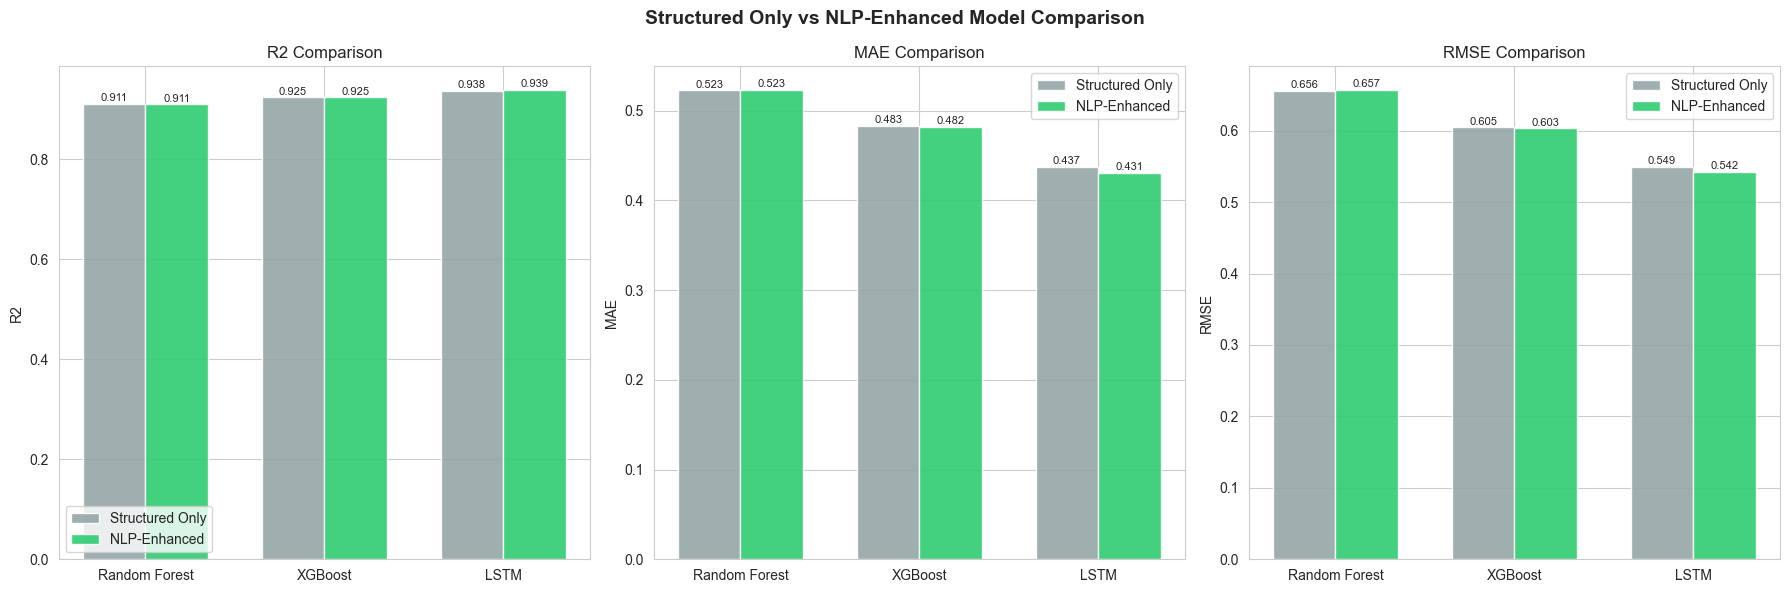

In [18]:
# -----------------------------------------------
# 6.3 - Grouped Bar Chart: Structured vs NLP-Enhanced
# -----------------------------------------------

models_base = ['RF (Structured Only)', 'XGB (Structured Only)', 'LSTM (Structured Only)']
models_nlp  = ['RF (NLP-Enhanced)',    'XGB (NLP-Enhanced)',    'LSTM (NLP-Enhanced)']
labels      = ['Random Forest', 'XGBoost', 'LSTM']

def get_metric(df, model_name, metric):
    row = df[df['Model'] == model_name]
    return row[metric].values[0] if len(row) > 0 else 0

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['R2', 'MAE', 'RMSE']
colors_base = '#95a5a6'
colors_nlp  = '#2ecc71'

x = np.arange(len(labels))
width = 0.35

for ax, metric in zip(axes, metrics):
    base_vals = [get_metric(final_df, m, metric) for m in models_base]
    nlp_vals  = [get_metric(final_df, m, metric) for m in models_nlp]

    b1 = ax.bar(x - width/2, base_vals, width, label='Structured Only', color=colors_base, alpha=0.9)
    b2 = ax.bar(x + width/2, nlp_vals,  width, label='NLP-Enhanced',    color=colors_nlp,  alpha=0.9)

    ax.set_title(f'{metric} Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel(metric)
    ax.legend()

    for bar in b1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    for bar in b2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Structured Only vs NLP-Enhanced Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/final_comparison_chart.png', dpi=150)
plt.show()

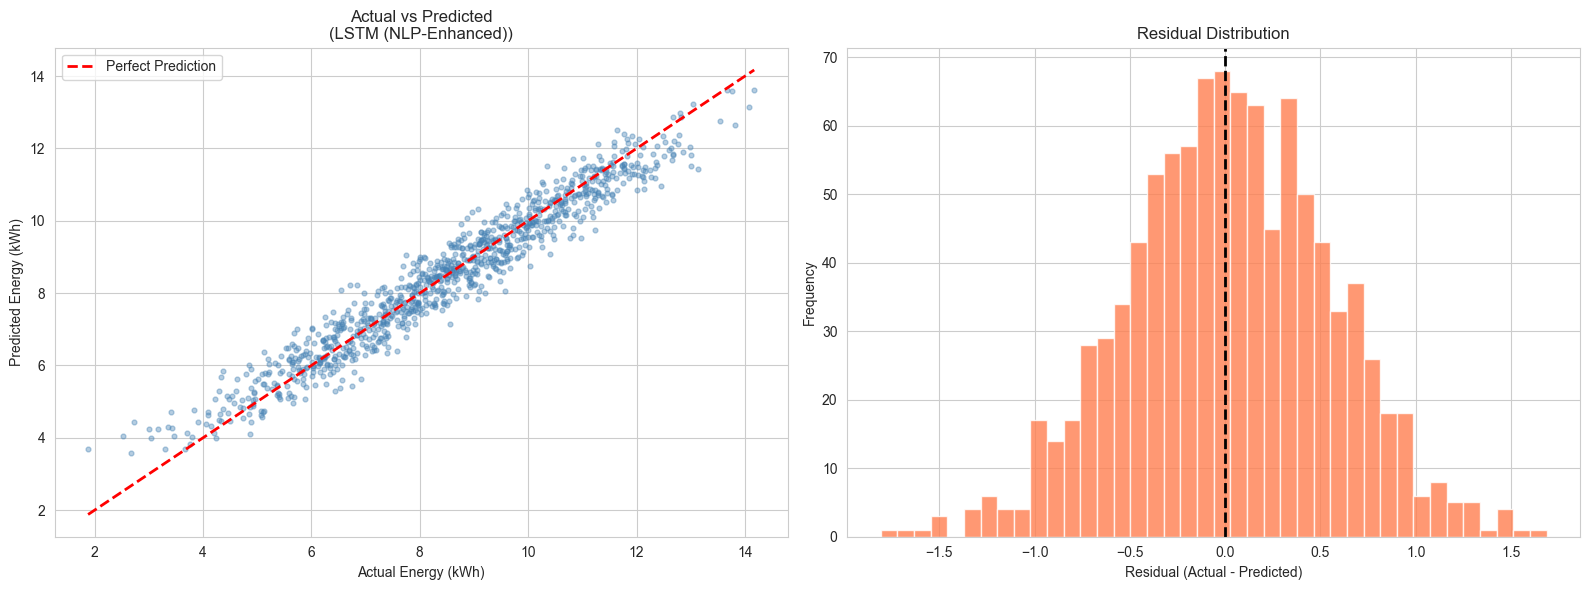

In [19]:
# -----------------------------------------------
# 6.4 - Actual vs Predicted: Best Model
# -----------------------------------------------

# Map model names to predictions
pred_map = {
    'RF (Structured Only)'      : rf_pred_base,
    'XGB (Structured Only)'     : xgb_pred_base,
    'LSTM (Structured Only)'    : lstm_pred_base,
    'RF (NLP-Enhanced)'         : rf_nlp_pred,
    'XGB (NLP-Enhanced)'        : xgb_nlp_pred,
    'LSTM (NLP-Enhanced)'       : lstm_nlp_pred,
    'Ensemble (Structured+NLP)' : ensemble_pred
}

best_pred = pred_map.get(best_final_model, ensemble_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
axes[0].scatter(y_test, best_pred, alpha=0.4, s=12, color='steelblue')
mn, mx = float(y_test.min()), float(y_test.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Energy (kWh)')
axes[0].set_ylabel('Predicted Energy (kWh)')
axes[0].set_title(f'Actual vs Predicted\n({best_final_model})')
axes[0].legend()

# Residuals
residuals = np.array(y_test) - best_pred
axes[1].hist(residuals, bins=40, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', lw=2)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('../results/best_model_actual_vs_predicted.png', dpi=150)
plt.show()

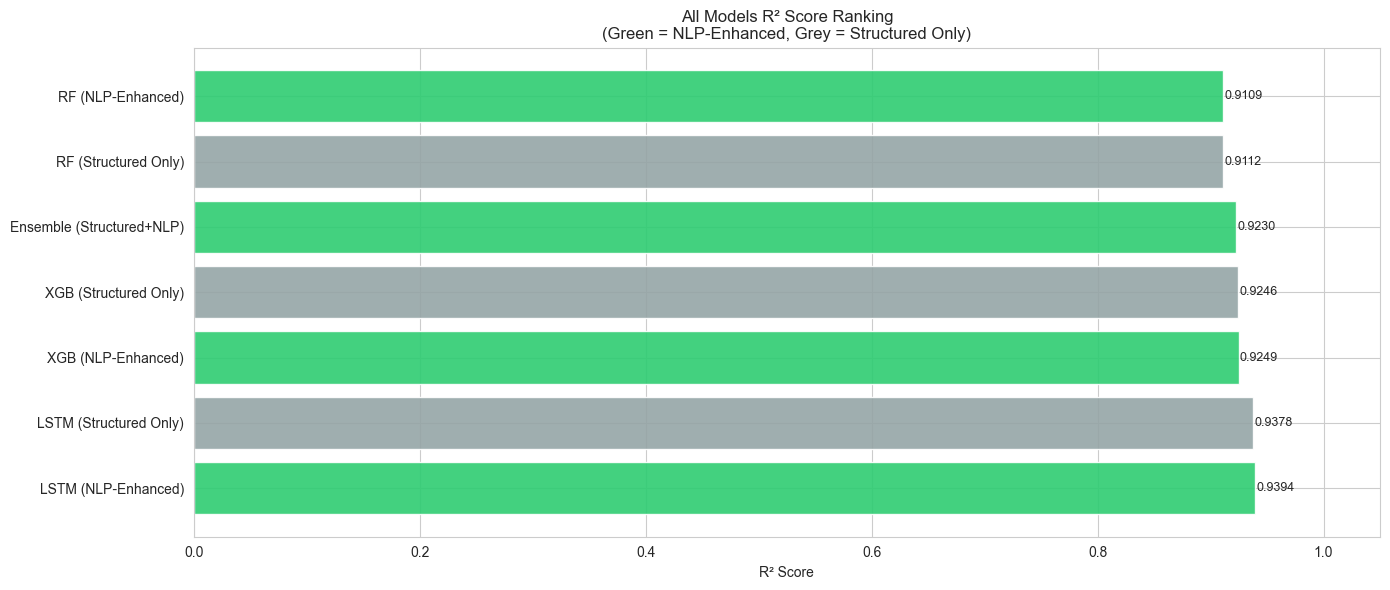

In [20]:
# -----------------------------------------------
# 6.5 - All Models R² Ranking Bar Chart
# -----------------------------------------------

plt.figure(figsize=(14, 6))
colors = ['#2ecc71' if 'NLP' in m or 'Ensemble' in m else '#95a5a6'
          for m in final_df['Model']]
bars = plt.barh(final_df['Model'], final_df['R2'], color=colors, alpha=0.9)

for bar, val in zip(bars, final_df['R2']):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

plt.xlabel('R² Score')
plt.title('All Models R² Score Ranking\n(Green = NLP-Enhanced, Grey = Structured Only)')
plt.xlim(0, 1.05)
plt.tight_layout()
plt.savefig('../results/r2_ranking.png', dpi=150)
plt.show()

## Step 7: Save Final Models & Predictions

In [21]:
os.makedirs('../saved_models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

# Save NLP-enhanced models
joblib.dump(rf_nlp,  '../saved_models/rf_nlp_model.pkl')
joblib.dump(xgb_nlp, '../saved_models/xgb_nlp_model.pkl')
lstm_nlp.save('../saved_models/lstm_nlp_model.h5')
print('NLP-enhanced models saved!')

# Save PCA transformer
joblib.dump(pca, '../saved_models/pca_transformer.pkl')
print('PCA transformer saved!')

# Save final results
final_df.to_csv('../results/final_model_comparison.csv', index=False)
print('Final results CSV saved!')

# Save final predictions
final_preds_df = pd.DataFrame({
    'Actual'                  : y_test.values,
    'RF_Structured'           : rf_pred_base,
    'XGB_Structured'          : xgb_pred_base,
    'LSTM_Structured'         : lstm_pred_base,
    'RF_NLP'                  : rf_nlp_pred,
    'XGB_NLP'                 : xgb_nlp_pred,
    'LSTM_NLP'                : lstm_nlp_pred,
    'Ensemble'                : ensemble_pred
})
final_preds_df.to_csv('../results/final_predictions.csv', index=False)
print('Final predictions saved!')

NLP-enhanced models saved!
PCA transformer saved!
Final results CSV saved!
Final predictions saved!


In [22]:
print('='*65)
print('NOTEBOOK 3 COMPLETE — PROJECT IMPLEMENTATION DONE!')
print('='*65)
print(f'\nBest Overall Model : {best_final_model}')
print(f'Best R²            : {final_df.iloc[0]["R2"]:.4f}')
print(f'Best MAE           : {final_df.iloc[0]["MAE"]:.4f} kWh')
print(f'Best RMSE          : {final_df.iloc[0]["RMSE"]:.4f} kWh')
print('\nFiles saved:')
print('  saved_models/rf_nlp_model.pkl')
print('  saved_models/xgb_nlp_model.pkl')
print('  saved_models/lstm_nlp_model.h5')
print('  saved_models/pca_transformer.pkl')
print('  results/final_model_comparison.csv')
print('  results/final_predictions.csv')
print('  results/final_comparison_chart.png')
print('  results/r2_ranking.png')
print('  results/best_model_actual_vs_predicted.png')
print('\nReady to write the research paper!')

NOTEBOOK 3 COMPLETE — PROJECT IMPLEMENTATION DONE!

Best Overall Model : LSTM (NLP-Enhanced)
Best R²            : 0.9394
Best MAE           : 0.4311 kWh
Best RMSE          : 0.5420 kWh

Files saved:
  saved_models/rf_nlp_model.pkl
  saved_models/xgb_nlp_model.pkl
  saved_models/lstm_nlp_model.h5
  saved_models/pca_transformer.pkl
  results/final_model_comparison.csv
  results/final_predictions.csv
  results/final_comparison_chart.png
  results/r2_ranking.png
  results/best_model_actual_vs_predicted.png

Ready to write the research paper!
